In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as dates
from datetime import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import pygwalker as pyg
import squarify

In [4]:
# 시스템 명령어로 폰트 설치 (Docker/Jupyter 환경)
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

# matplotlib 버전 확인
import matplotlib as mpl
print(f"Matplotlib 버전: {mpl.__version__}")

# 버전에 따른 폰트 캐시 재구성
try:
    # 최신 버전
    from matplotlib import font_manager
    font_manager.fontManager.addfont('../../fonts/NanumGothic.ttf')
except:
    try:
        # 이전 버전
        mpl.font_manager._rebuild()
    except:
        # 가장 이전 버전
        import matplotlib.font_manager as fm
        fm._rebuild()
        
# 설치된 폰트 확인
import matplotlib.font_manager as fm
fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print("설치된 나눔 폰트:", fonts)

Matplotlib 버전: 3.10.1
설치된 나눔 폰트: ['NanumMyeongjo', 'NanumBarunGothic', 'NanumMyeongjo', 'NanumSquareRound', 'NanumBarunGothic', 'NanumGothic', 'NanumGothic', 'NanumSquare', 'NanumSquare', 'NanumSquareRound', 'NanumGothic']


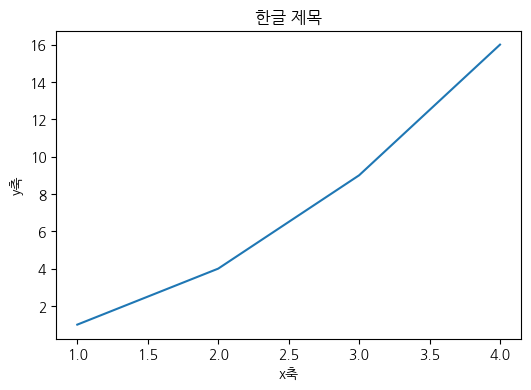

In [5]:
# 나눔고딕 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 간단한 예시 플롯
plt.figure(figsize=(6,4))
plt.plot([1, 2, 3, 4], [1, 4, 9, 16])
plt.title("한글 제목")
plt.xlabel("x축")
plt.ylabel("y축")
plt.show()


In [6]:
df = pd.read_parquet('../data/train.parquet')

In [7]:
df

,user_id,item_id,user_session,event_time,category_code,brand,price,event_type
0,0b517454-e7c3-44ec-8c39-a68ef9c0ec60,18c11cbb-a18d-4a9e-bdea-6abd3f7d3c04,ad97f19a-f5fb-41ea-a7b2-52c21fb37ab2,2019-11-16 16:31:26 UTC,apparel.shoes,kapika,72.05,view
1,215eeee5-f9c5-4213-8641-7561dbdad1b9,47c5a6da-32d0-4a29-8b51-57304f476ded,6058b45b-bdb9-4d6c-b300-42dcb1cb8280,2019-11-04 18:59:50 UTC,apparel.shoes,respect,82.63,view
2,a25bf14a-49ac-49bb-87de-ee6b300f0cc4,a6d915c6-2bb7-4393-a556-c327723d3666,28a8b8e3-b374-435d-9d5d-b96058ecb75b,2019-11-26 09:01:47 UTC,apparel.tshirt,goodloot,24.43,view
3,09ee8591-25e0-4bb4-ae24-c48ed4212e3c,0fd4da5d-989c-4a75-9ace-2b108f834c8c,f2972db7-9916-4a58-b6f9-c76afde6245e,2019-11-15 16:05:34 UTC,apparel.shoes,baden,70.79,view
4,7acf7c81-69f6-4aa8-b19f-8e85aeaffc28,d52d1c91-5534-4de4-aaf1-318e932e10e7,7d46d970-b40e-4a2f-81a7-65bf23aa0aae,2019-11-16 13:14:09 UTC,apparel.shoes,rooman,53.80,view
...,...,...,...,...,...,...,...,...
8350306,54cab296-76c9-4bb1-8566-79249eaaa1b5,5412e9c1-6014-4dc0-afe1-07d824a4868c,a2b7eac9-7349-4b73-83ec-51007b5bbded,2020-02-11 08:42:04 UTC,apparel.shoes,samsung,25.46,view
8350307,4152e35a-c9de-4939-a2b9-eb3f354ed55e,9a5e8978-90a6-4c3d-bb39-2ec931df49e4,13f82f24-4066-48ae-88f2-0edb246dceef,2020-02-05 10:38:15 UTC,apparel.shoes,respect,47.36,view
8350308,4152e35a-c9de-4939-a2b9-eb3f354ed55e,efb939cd-0b44-4ccb-aeb1-8bf0b71068e8,13f82f24-4066-48ae-88f2-0edb246dceef,2020-02-05 10:38:27 UTC,apparel.shoes,rieker,73.36,view
8350309,4152e35a-c9de-4939-a2b9-eb3f354ed55e,1538c2ae-b7f0-437d-a4e9-9d955cdc07b7,13f82f24-4066-48ae-88f2-0edb246dceef,2020-02-05 10:39:19 UTC,apparel.shoes,respect,89.84,view


In [8]:
visitor_daily_trend = df.loc[:,['event_time','user_id']]

visitor_daily_trend['event_time'] = visitor_daily_trend['event_time'].apply(lambda s: str(s)[0:10])


In [9]:
visitor_by_date = (visitor_daily_trend.drop_duplicates()
                  .groupby(['event_time'])['user_id']
                  .agg(['count'])
                  .sort_values(by=['event_time'], ascending=True))

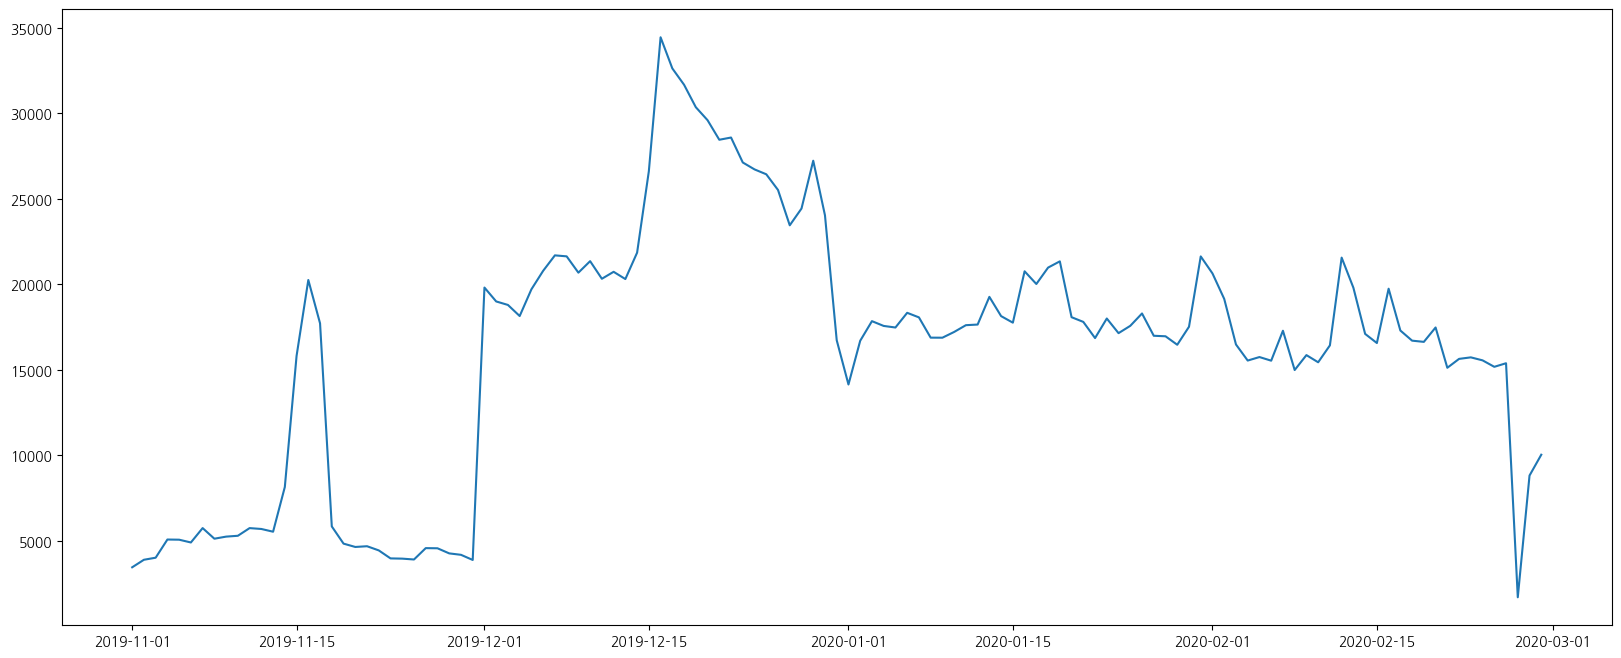

In [10]:
x = (pd.Series(visitor_by_date.index.values)
     .apply(lambda s: datetime.strptime(s, '%Y-%m-%d').date()))

y = visitor_by_date['count']
plt.rcParams['figure.figsize'] = (20, 8)

plt.plot(x,y)
plt.show()

In [11]:
# 모든 고유 값 확인
unique_categories = df['category_code'].unique()
print(unique_categories)

# 고유 값 개수 확인
num_categories = df['category_code'].nunique()
print(f"고유 카테고리 수: {num_categories}")


['apparel.shoes' 'apparel.tshirt' 'apparel.skirt' 'apparel.shoes.keds'
 'apparel.shoes.moccasins' 'apparel.dress' 'apparel.costume'
 'apparel.jumper' 'apparel.glove' 'apparel.trousers' 'apparel.underwear'
 'apparel.shirt' 'apparel.shoes.sandals' 'apparel.jeans'
 'apparel.shoes.ballet_shoes' 'apparel.scarf' 'apparel.shoes.espadrilles'
 'apparel.shoes.slipons' 'apparel.shoes.step_ins' 'apparel.belt'
 'apparel.sock' 'apparel.shorts' 'apparel.pajamas' 'apparel.jacket']
고유 카테고리 수: 24


In [12]:
# 값 빈도 확인
category_counts = df['category_code'].value_counts()
print(category_counts)


category_code
apparel.shoes                 2960539
apparel.shoes.keds            1035117
apparel.shoes.slipons          756754
apparel.shoes.sandals          592478
apparel.costume                424789
apparel.underwear              413119
apparel.scarf                  380521
apparel.shirt                  346004
apparel.shoes.moccasins        259753
apparel.shorts                 192148
apparel.shoes.step_ins         172520
apparel.trousers               150486
apparel.tshirt                 134430
apparel.jeans                   91158
apparel.shoes.ballet_shoes      78157
apparel.pajamas                 75274
apparel.jumper                  67274
apparel.dress                   65851
apparel.sock                    45491
apparel.shoes.espadrilles       41941
apparel.glove                   32365
apparel.skirt                   23283
apparel.jacket                   5602
apparel.belt                     5257
Name: count, dtype: int64


#### 어떤 아이템들을 가장 많이 샀는가?

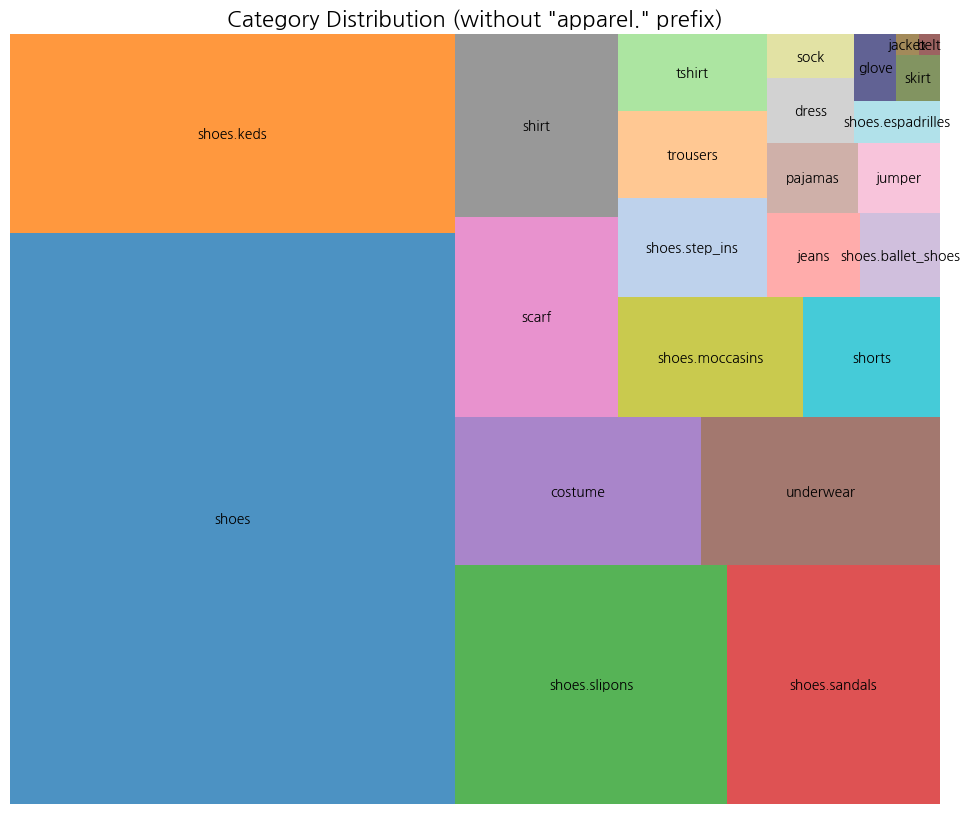

In [13]:
# 원본 데이터 복사본 만들기
df_viz = df.copy()

# 'apparel.' 접두사 제거
df_viz['category_code'] = df_viz['category_code'].str.replace('apparel.', '')

# 카테고리 빈도 계산
categories = df_viz['category_code'].value_counts().sort_values(ascending=False)

# 시각화
import squarify
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
squarify.plot(sizes=categories, label=categories.index, alpha=0.8, color=[
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5",
    "#c49c94", "#f7b6d2", "#c7c7c7", "#dbdb8d", "#9edae5",
    "#393b79", "#637939", "#8c6d31", "#843c39"
])
plt.title('Category Distribution (without "apparel." prefix)', fontsize=16)
plt.axis('off')
plt.show()

#### 어떤 아이템들을 가장 많이 샀는가? (Bar_Graph)

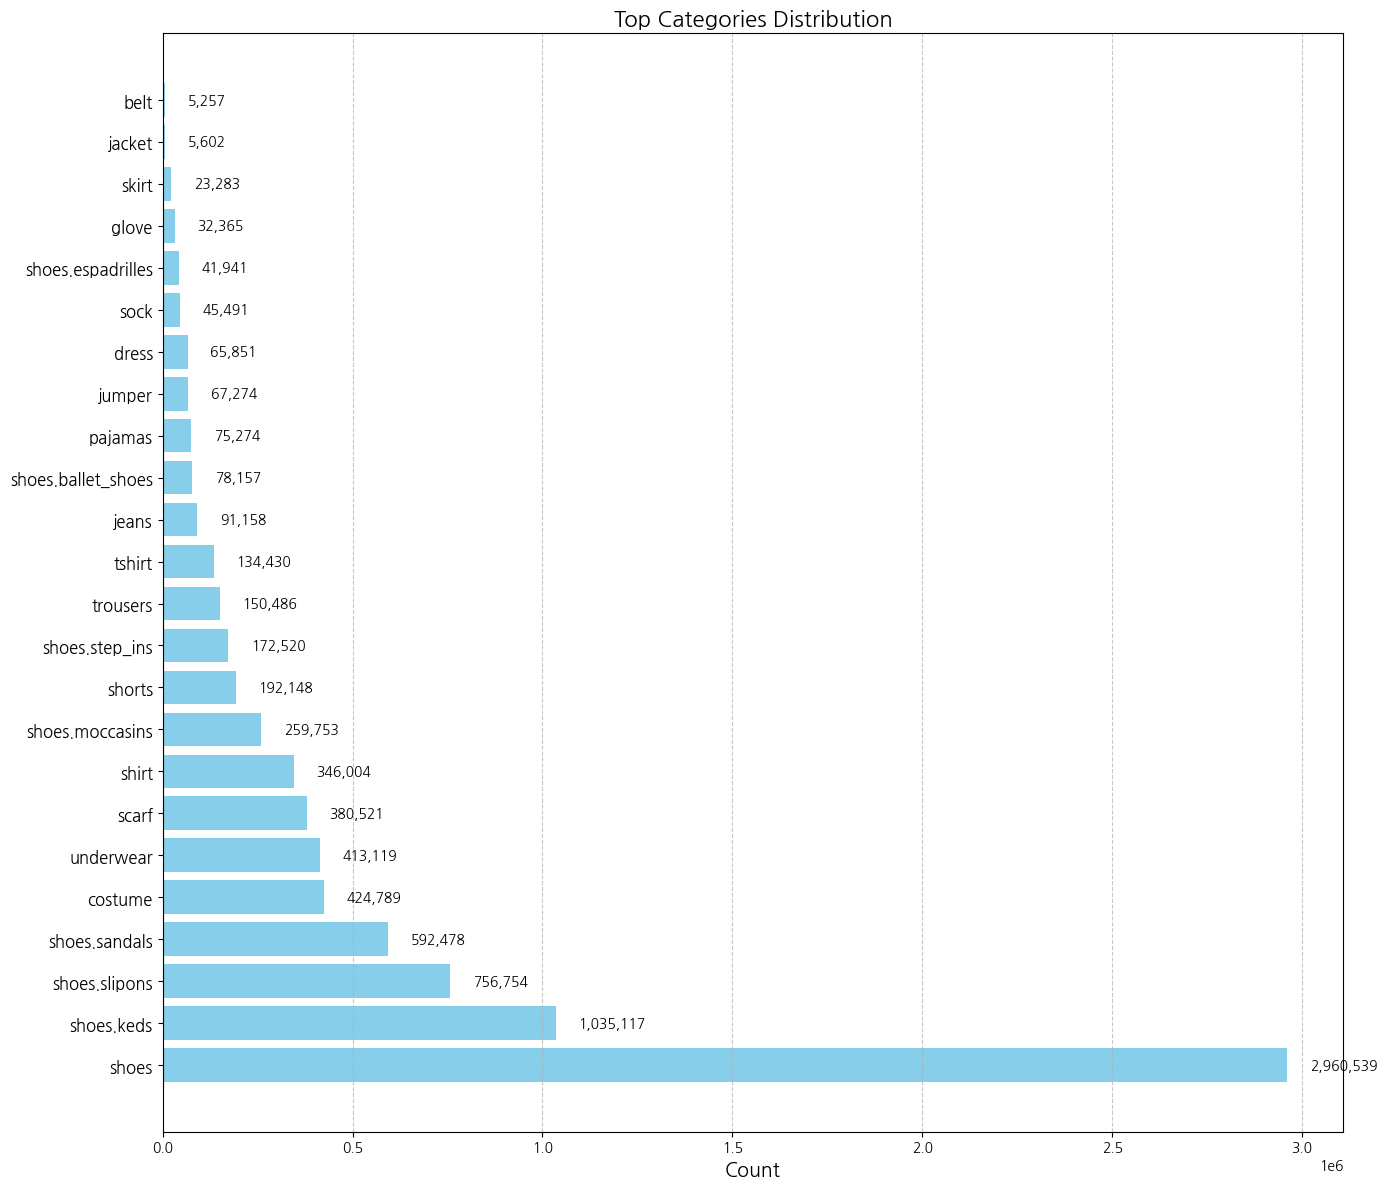

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 원본 데이터 복사본 만들기
df_viz = df.copy()

# 'apparel.' 접두사 제거
df_viz['category_code'] = df_viz['category_code'].str.replace('apparel.', '')

# 카테고리 빈도 계산 
categories = df_viz['category_code'].value_counts().sort_values(ascending=False)

# 그래프 크기 설정 - 카테고리 수에 따라 높이 조정
plt.figure(figsize=(14, 12))  # 가로 길이를 넓게 설정

# 가로 막대 그래프 생성
bars = plt.barh(np.arange(len(categories)), categories.values, color='skyblue')

# 막대 끝에 값 표시
for i, (value, name) in enumerate(zip(categories.values, categories.index)):
    plt.text(value + (categories.max() * 0.02), i, f'{value:,}', 
             va='center', fontsize=10)

# y축 레이블 설정 (카테고리명)
plt.yticks(np.arange(len(categories)), categories.index, fontsize=12)

# 축 레이블 및 제목
plt.xlabel('Count', fontsize=14)
plt.title('Top Categories Distribution', fontsize=16)

# 그리드 추가 (x축만)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 레이아웃 조정
plt.tight_layout()
plt.show()

#### Event Type 에는 어떤 것들이 있는가?

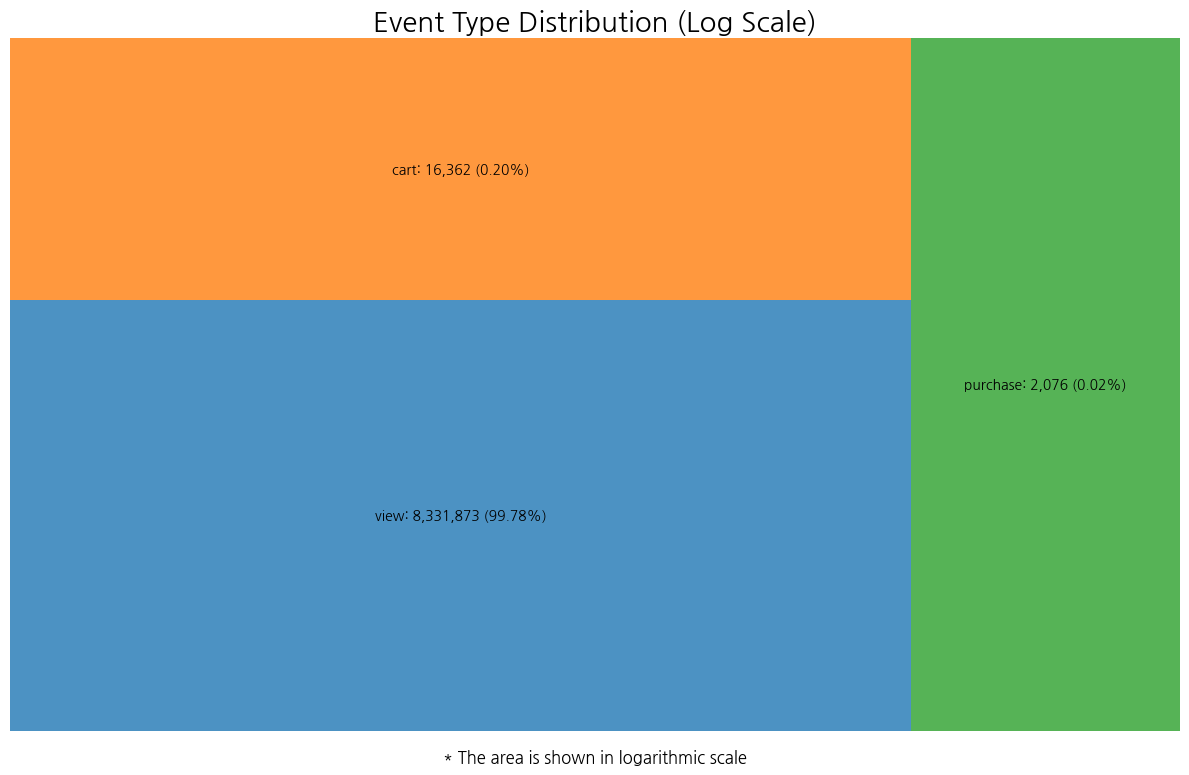

In [15]:
import numpy as np
import squarify
import matplotlib.pyplot as plt

# 데이터 준비 (예시)
event_types = ['view', 'cart', 'purchase']
sizes = df['event_type'].value_counts()

# 원래 백분율 계산 (레이블용)
percentages = 100 * sizes / sizes.sum()

# 로그 스케일 적용 (0이 없도록 1 더하기)
log_sizes = np.log1p(sizes)

# 레이블에 원래 개수와 백분율 표시
labels = [f'{event}: {count:,} ({percentage:.2f}%)' 
          for event, count, percentage in zip(event_types, sizes, percentages)]

# 색상 설정
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# 트리맵 그리기
plt.figure(figsize=(12, 8))
squarify.plot(sizes=log_sizes, label=labels, color=colors, alpha=0.8)
plt.title('Event Type Distribution (Log Scale)', fontsize=20)
plt.axis('off')

# 로그 스케일 적용 표시
plt.figtext(0.5, 0.01, '* The area is shown in logarithmic scale', 
            ha='center', fontsize=12, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # 하단 텍스트 공간 확보
plt.show()

#### Event Type = "구매" 일 경우 어떤 아이템을 가장 많이 샀는가?

In [16]:
purchase_item = df.loc[df['event_type'] == 'purchase']
purchase_item = purchase_item.dropna(axis='rows')
purchase_item.head()

,user_id,item_id,user_session,event_time,category_code,brand,price,event_type
2660,3308e1fb-9ba3-4d5d-b6d7-b69327d1eaf9,f9c5fb98-9577-44a9-b946-d18bc45b8368,8f310373-d270-41b1-8657-17ad43fd44b8,2019-11-13 13:40:01 UTC,apparel.shoes,nexpero,75.42,purchase
16872,5a9f26f1-972d-4918-b1ee-73df61d495a0,13eebd7f-62c2-4859-8396-5f4c5c92410c,deb74236-4182-48b7-9d01-0fa77f69b4fc,2019-11-16 14:29:53 UTC,apparel.shoes,respect,84.43,purchase
35132,174c647c-663d-418a-9f32-223cfe80e823,0dd57aac-9857-4749-b636-61e40132d609,670edfa2-98b0-463e-a553-1e72e6a25537,2019-11-17 10:16:37 UTC,apparel.shoes,respect,82.63,purchase
62514,0cd7faa5-eda0-4544-8d7c-4fb43f41eb65,b6a07470-4084-40c3-9349-7e1275cc1150,89df019f-d1b4-43fd-b04f-c3a51ce9bcc4,2019-11-17 06:54:27 UTC,apparel.shoes,baden,71.82,purchase
84596,d7fb91c9-b1ad-4224-b109-7c5f3a936715,fb5a01f5-7261-4de0-94d1-9d75d4792185,6167e9f8-5009-4a1a-8789-efe5e29f4431,2019-11-17 05:48:23 UTC,apparel.shoes,baden,86.23,purchase


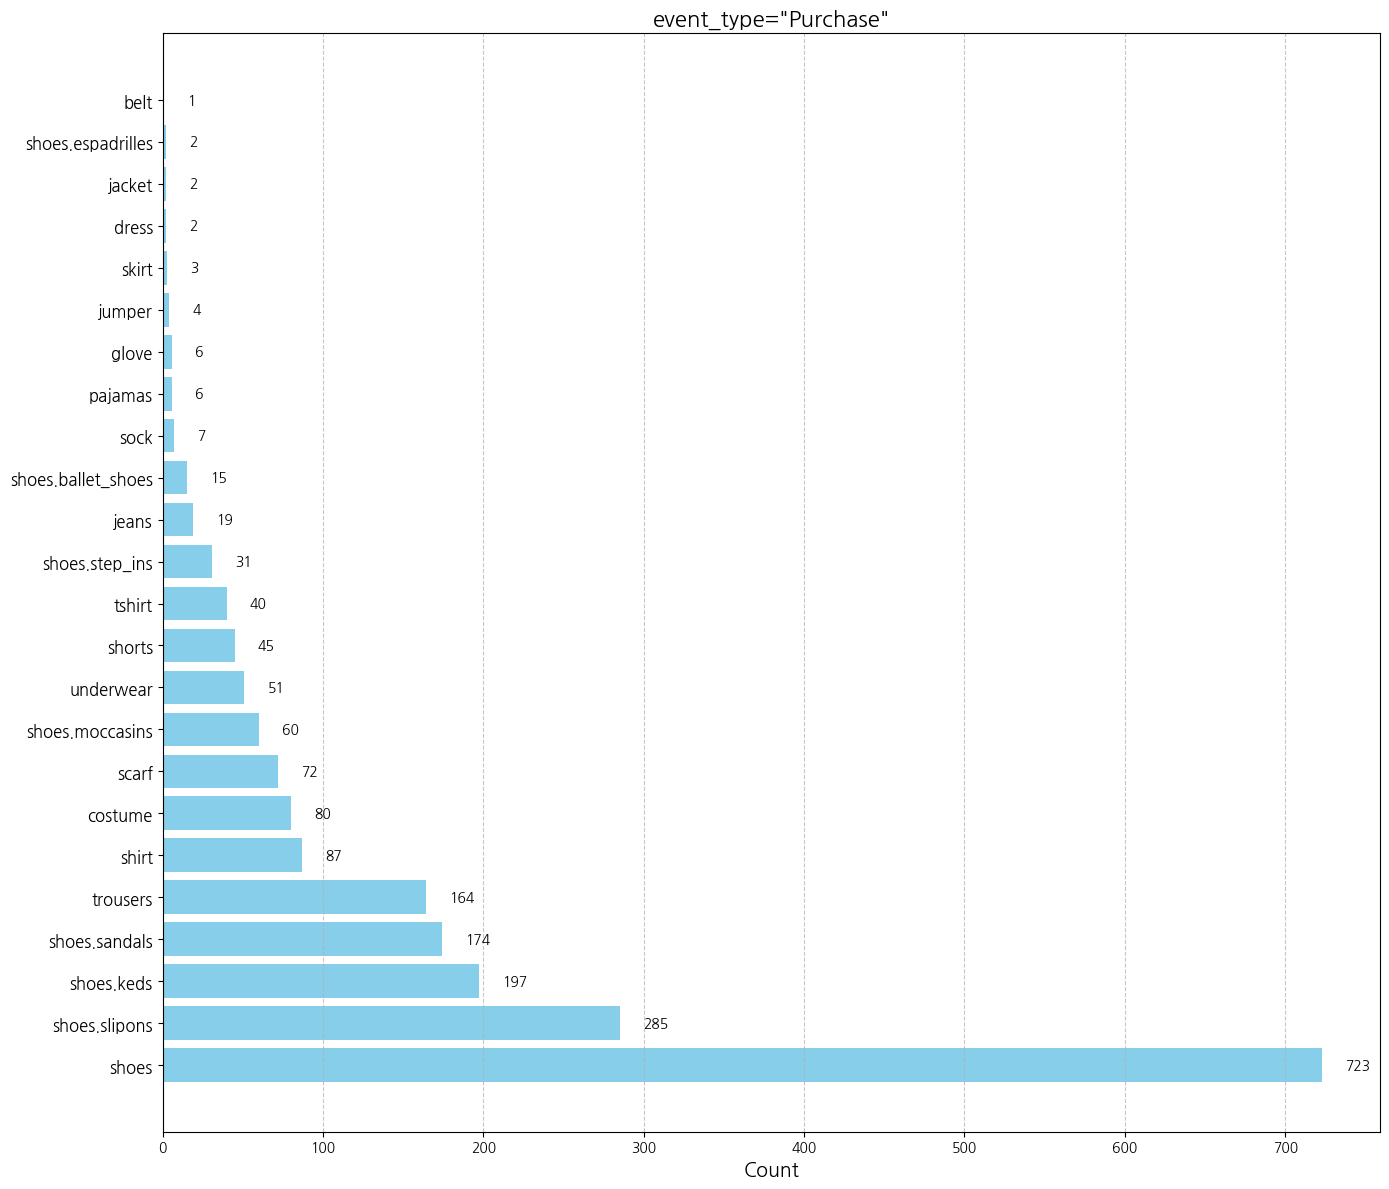

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 'apparel.' 접두사 제거
purchase_item['category_code'] = purchase_item['category_code'].str.replace('apparel.', '')

# 카테고리 빈도 계산 
categories = purchase_item['category_code'].value_counts().sort_values(ascending=False)

# 그래프 크기 설정 - 카테고리 수에 따라 높이 조정
plt.figure(figsize=(14, 12))  # 가로 길이를 넓게 설정

# 가로 막대 그래프 생성
bars = plt.barh(np.arange(len(categories)), categories.values, color='skyblue')

# 막대 끝에 값 표시
for i, (value, name) in enumerate(zip(categories.values, categories.index)):
    plt.text(value + (categories.max() * 0.02), i, f'{value:,}', 
             va='center', fontsize=10)

# y축 레이블 설정 (카테고리명)
plt.yticks(np.arange(len(categories)), categories.index, fontsize=12)

# 축 레이블 및 제목
plt.xlabel('Count', fontsize=14)
plt.title('event_type="Purchase"', fontsize=16)

# 그리드 추가 (x축만)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 레이아웃 조정
plt.tight_layout()
plt.show()

#### 구매한 사람들은 어떤 브랜드를 사는가?

In [18]:
brands = purchase_item.groupby('brand')['brand'].agg(['count']).sort_values('count', ascending=False)
# Brand 상위 20
brands.head(20)

,count
brand,
xiaomi,224
sony,180
samsung,112
iqos,101
respect,74
apple,51
defacto,50
luminarc,43
glo,43


##### View2cart, view2purchase, cart2purchase rate 정보를 구매 예측에 어떻게 활용할 수 있을까?

이벤트 기반 전환율 (Event-based Conversion Rate)

- 각 이벤트가 다음 단계로 전환되는 비율을 보여줌
- 모든 제품 조회 중 몇 %가 장바구니에 추가되는가?"

In [19]:
# 이벤트 수 기반 전환율
view_events = df[df['event_type'] == 'view'].shape[0]
cart_events = df[df['event_type'] == 'cart'].shape[0]
purchase_events = df[df['event_type'] == 'purchase'].shape[0]

# 이벤트 기반 전환율 계산
event_view2cart = cart_events / view_events
event_view2purchase = purchase_events / view_events
event_cart2purchase = purchase_events / cart_events

print(f"이벤트 기반 View to Cart 전환율: {event_view2cart:.4f}")
print(f"이벤트 기반 View to Purchase 전환율: {event_view2purchase:.4f}")
print(f"이벤트 기반 Cart to Purchase 전환율: {event_cart2purchase:.4f}")

이벤트 기반 View to Cart 전환율: 0.0020
이벤트 기반 View to Purchase 전환율: 0.0002
이벤트 기반 Cart to Purchase 전환율: 0.1269


사용자 기반 전환율 (User-based Conversion Rate)

- 사용자의 행동 패턴을 보여줌
- 제품을 본 사용자 중 몇 %가 장바구니에 추가하는가?"

In [20]:
# 고유 사용자 수 기반 전환율
view_users = df[df['event_type'] == 'view']['user_id'].nunique()
cart_users = df[df['event_type'] == 'cart']['user_id'].nunique()
purchase_users = df[df['event_type'] == 'purchase']['user_id'].nunique()

# 사용자 기반 전환율 계산
user_view2cart = cart_users / view_users
user_view2purchase = purchase_users / view_users
user_cart2purchase = purchase_users / cart_users

print(f"사용자 기반 View to Cart 전환율: {user_view2cart:.4f}")
print(f"사용자 기반 View to Purchase 전환율: {user_view2purchase:.4f}")
print(f"사용자 기반 Cart to Purchase 전환율: {user_cart2purchase:.4f}")

사용자 기반 View to Cart 전환율: 0.0164
사용자 기반 View to Purchase 전환율: 0.0026
사용자 기반 Cart to Purchase 전환율: 0.1604


In [21]:
# 세션 기반 전환율
view_sessions = df[df['event_type'] == 'view']['user_session'].nunique()
cart_sessions = df[df['event_type'] == 'cart']['user_session'].nunique()
purchase_sessions = df[df['event_type'] == 'purchase']['user_session'].nunique()

session_view2cart = cart_sessions / view_sessions
session_view2purchase = purchase_sessions / view_sessions

print(f"섹션 기반 View to Cart 전환율: {session_view2cart:.4f}")
print(f"섹션 기반 View to Purchase 전환율: {session_view2purchase:.4f}")

섹션 기반 View to Cart 전환율: 0.0055
섹션 기반 View to Purchase 전환율: 0.0007


event_type     view  cart  purchase  view2cart  view2purchase  cart2purchase
year_month                                                                  
2019-11     1231025   257        94     0.0002         0.0001         0.3658
2019-12     3000807  1626       137     0.0005         0.0000         0.0843
2020-01     2236253  7077       260     0.0032         0.0001         0.0367
2020-02     1863788  7402      1585     0.0040         0.0009         0.2141


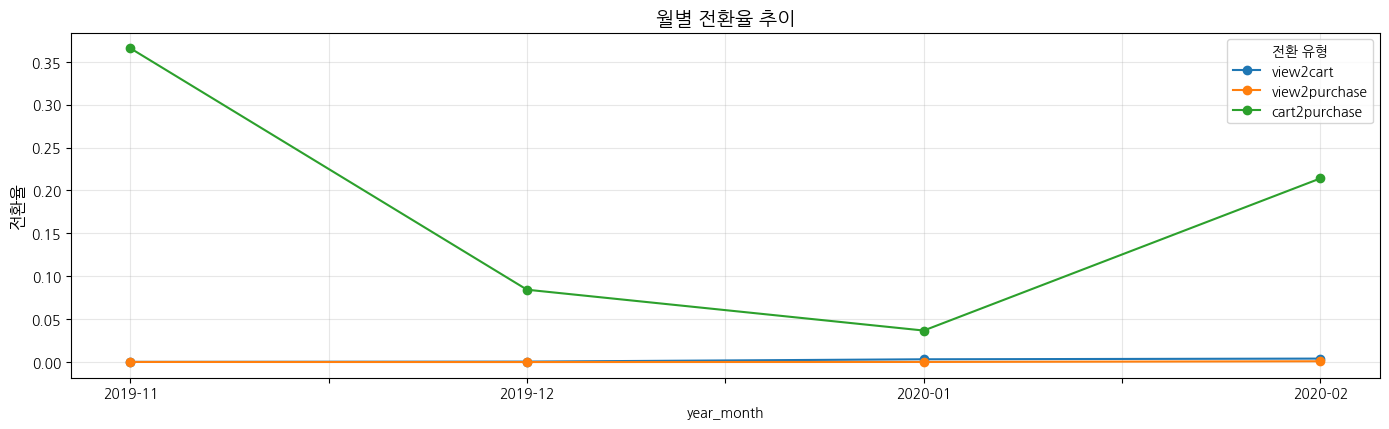

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# event_time을 datetime 형식으로 변환 (이미 datetime 형식이라면 이 단계 생략)
df['event_time'] = pd.to_datetime(df['event_time'])

# 년도와 월 추출
df['year_month'] = df['event_time'].dt.strftime('%Y-%m')

# 년도-월별, 이벤트 타입별 집계
monthly_events = df.groupby(['year_month', 'event_type']).size().unstack().fillna(0)

# 이벤트 기반 전환율 계산
monthly_events['view2cart'] = monthly_events['cart'] / monthly_events['view']
monthly_events['view2purchase'] = monthly_events['purchase'] / monthly_events['view']
monthly_events['cart2purchase'] = monthly_events['purchase'] / monthly_events['cart']

# 소수점 4자리까지 반올림
monthly_events['view2cart'] = monthly_events['view2cart'].round(4)
monthly_events['view2purchase'] = monthly_events['view2purchase'].round(4)
monthly_events['cart2purchase'] = monthly_events['cart2purchase'].round(4)

# 결과 확인
print(monthly_events[['view', 'cart', 'purchase', 'view2cart', 'view2purchase', 'cart2purchase']])

# 시각화
plt.figure(figsize=(14, 8))

# 전환율 추이 그래프
plt.subplot(2, 1, 1)
monthly_events[['view2cart', 'view2purchase', 'cart2purchase']].plot(marker='o', ax=plt.gca())
plt.title('월별 전환율 추이', fontsize=14)
plt.ylabel('전환율', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='전환 유형')

# # 이벤트 수 추이 그래프 (로그 스케일)
# plt.subplot(2, 1, 2)
# monthly_events[['view', 'cart', 'purchase']].plot(marker='o', ax=plt.gca())
# plt.title('월별 이벤트 수 추이', fontsize=14)
# plt.ylabel('이벤트 수', fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.legend(title='이벤트 유형')

plt.tight_layout()
plt.show()

event_type     view  cart  purchase  view2cart  view2purchase  cart2purchase
year_month                                                                  
2019-11     1231025   257        94     0.0002         0.0001         0.3658
2019-12     3000807  1626       137     0.0005         0.0000         0.0843
2020-01     2236253  7077       260     0.0032         0.0001         0.0367
2020-02     1863788  7402      1585     0.0040         0.0009         0.2141


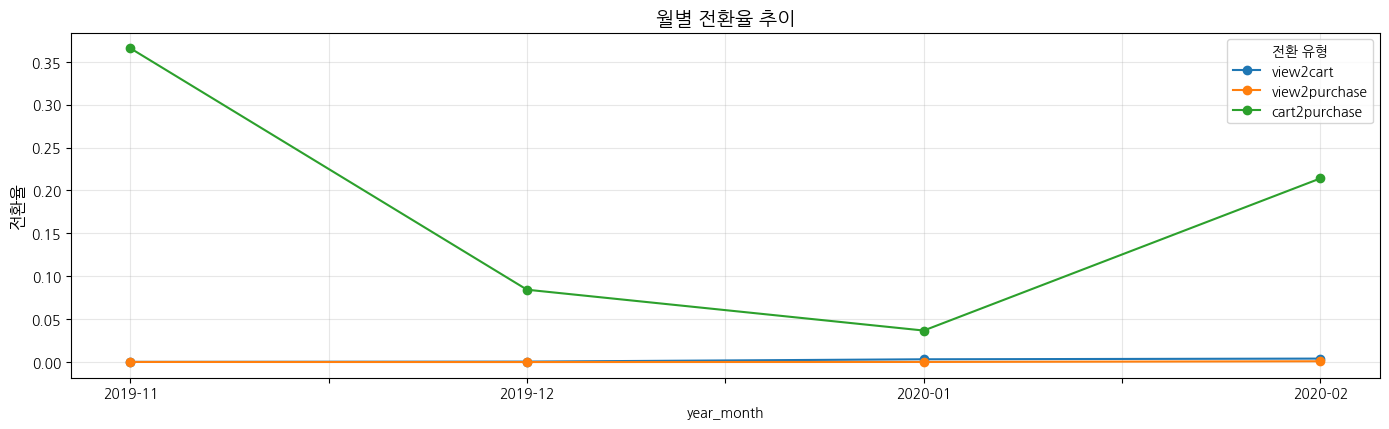

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# event_time을 datetime 형식으로 변환 (이미 datetime 형식이라면 이 단계 생략)
df['event_time'] = pd.to_datetime(df['event_time'])

# 년도와 월 추출
df['year_month'] = df['event_time'].dt.strftime('%Y-%m')

# 년도-월별, 이벤트 타입별 집계
monthly_events = df.groupby(['year_month', 'event_type']).size().unstack().fillna(0)

# 이벤트 기반 전환율 계산
monthly_events['view2cart'] = monthly_events['cart'] / monthly_events['view']
monthly_events['view2purchase'] = monthly_events['purchase'] / monthly_events['view']
monthly_events['cart2purchase'] = monthly_events['purchase'] / monthly_events['cart']

# 소수점 4자리까지 반올림
monthly_events['view2cart'] = monthly_events['view2cart'].round(4)
monthly_events['view2purchase'] = monthly_events['view2purchase'].round(4)
monthly_events['cart2purchase'] = monthly_events['cart2purchase'].round(4)

# 결과 확인
print(monthly_events[['view', 'cart', 'purchase', 'view2cart', 'view2purchase', 'cart2purchase']])

# 시각화
plt.figure(figsize=(14, 8))

# 전환율 추이 그래프
plt.subplot(2, 1, 1)
monthly_events[['view2cart', 'view2purchase', 'cart2purchase']].plot(marker='o', ax=plt.gca())
plt.title('월별 전환율 추이', fontsize=14)
plt.ylabel('전환율', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='전환 유형')


plt.tight_layout()
plt.show()